# Project 1 — Notebook 03: NCR Zone Performance Analysis
### Detailed zone-level KPI breakdown for NCR (Region 3)

---

### Ticket Lifecycle Reference

```
REPORTDATE ──────────────► DISPATCHDATE ──────────────► RESOLVEDDATE
     │                           │                            │
     │◄── NOC/ROC Time ─────────►│◄──── Field Engr Time ─────►│
     │                                                         │
     │◄────────────────── Total MTTR (OUTAGEDURATION) ────────►│
```

| Metric | Formula | Note |
|--------|---------|------|
| **NOC/ROC Time** | `DISPATCHDATE − REPORTDATE` | Remote troubleshooting phase. Zero is valid — some faults immediately identified as field-only |
| **Field Engineer Time** | `RESOLVEDDATE − DISPATCHDATE` | On-site resolution phase |
| **Total MTTR** | `OUTAGEDURATION` | Full cycle |

> **Data quality note:** Phase time metrics (NOC/ROC Time and Field Time) are computed
> only on tickets where `Timestamp_Integrity = True`. Tickets where DISPATCHDATE was
> recorded after RESOLVEDDATE are excluded from phase aggregations but retained in
> volume and SLA calculations. See Notebook 02 Section 7 for full details.

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
summary = calculate_zone_summary(df)   # Timestamp_Integrity filter applied inside

z = {row['ZONE']: row for _, row in summary.iterrows()}
z5, z4, z2, z3, z1, z6 = (z.get(f'ZONE {i}') for i in [5,4,2,3,1,6])
total_tickets = summary['Ticket_Count'].sum()

print(f"✅ {total_tickets:,} tickets · {len(summary)} zones")
print(f"   Columns: {list(summary.columns)}")

# Confirm Timestamp_Integrity filter was applied
if 'Timestamp_Integrity' in df.columns:
    bad = (~df['Timestamp_Integrity']).sum()
    print(f"   Corrupt timestamp tickets excluded from phase metrics: {bad:,}")

✅ 36,907 tickets · 6 zones
   Columns: ['ZONE', 'Ticket_Count', 'MTTR', 'SLA_Compliance_Rate', 'Total_Faults', 'Unique_Sites', 'Fault_Density', 'Avg_NOC_Time', 'Avg_Field_Time']
   Corrupt timestamp tickets excluded from phase metrics: 1,465


## 2. Zone Performance Comparison

In [2]:
cols = ['ZONE','Ticket_Count','MTTR','SLA_Compliance_Rate',
        'Avg_NOC_Time','Avg_Field_Time','Fault_Density','Unique_Sites']
display(summary[cols].reset_index(drop=True).style
    .hide(axis='index')
    .format({
        'Ticket_Count'        : '{:,.0f}',
        'MTTR'                : '{:.1f}h',
        'SLA_Compliance_Rate' : '{:.2f}%',
        'Avg_NOC_Time'        : '{:.1f}h',
        'Avg_Field_Time'      : '{:.1f}h',
        'Fault_Density'       : '{:.2f}',
        'Unique_Sites'        : '{:,.0f}',
    })
    .background_gradient(subset=['SLA_Compliance_Rate'], cmap='Greens',   vmin=84, vmax=92)
    .background_gradient(subset=['MTTR'],                cmap='RdYlGn_r', vmin=30, vmax=80)
    .background_gradient(subset=['Avg_NOC_Time'],        cmap='RdYlGn_r', vmin=0,  vmax=20)
    .background_gradient(subset=['Avg_Field_Time'],      cmap='RdYlGn_r', vmin=30, vmax=85)
    .background_gradient(subset=['Fault_Density'],       cmap='RdYlGn_r', vmin=6,  vmax=10)
    .set_caption(
        'Table 1 — Zone KPI Summary  |  '
        'NOC Time = DISPATCHDATE − REPORTDATE  |  '
        'Field Time = RESOLVEDDATE − DISPATCHDATE  |  '
        'Phase metrics computed on timestamp-clean tickets only'
    )
    .set_table_styles([
        {'selector':'caption','props':[('font-size','12px'),('font-weight','bold'),
                                       ('text-align','left'),('padding-bottom','6px')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)

ZONE,Ticket_Count,MTTR,SLA_Compliance_Rate,Avg_NOC_Time,Avg_Field_Time,Fault_Density,Unique_Sites
ZONE 5,"9,131",77.8h,79.59%,0.1h,80.7h,8.62,"1,059"
ZONE 4,"7,952",47.4h,84.54%,6.7h,42.6h,7.65,"1,040"
ZONE 2,"7,307",51.0h,83.86%,0.1h,52.4h,7.01,"1,043"
ZONE 3,"4,393",32.3h,80.58%,0.1h,33.3h,6.60,666
ZONE 1,"4,306",62.6h,83.07%,15.8h,49.6h,9.44,456
ZONE 6,"3,818",70.0h,80.85%,0.1h,71.8h,8.00,477


## 3. KPI Rankings

In [3]:
rankings = [
    ('Total MTTR — lower is better',          'MTTR',                True,  '{:.1f}h'),
    ('SLA Compliance — higher is better',      'SLA_Compliance_Rate', False, '{:.2f}%'),
    ('NOC/ROC Time — lower is better',         'Avg_NOC_Time',        True,  '{:.1f}h'),
    ('Field Engineer Time — lower is better',  'Avg_Field_Time',      True,  '{:.1f}h'),
    ('Fault Density — lower is better',        'Fault_Density',       True,  '{:.2f}'),
]

for title, col, asc, fmt in rankings:
    ranked = (summary[['ZONE', col]]
              .sort_values(col, ascending=asc)
              .reset_index(drop=True))
    ranked.index = ranked.index + 1
    ranked.index.name = 'Rank'
    display(Markdown(f'### {title}'))
    display(ranked.style.format({col: fmt})
            .background_gradient(cmap='RdYlGn' if not asc else 'RdYlGn_r', subset=[col]))
    print()

### Total MTTR — lower is better

,ZONE,MTTR
Rank,,
1,ZONE 3,32.3h
2,ZONE 4,47.4h
3,ZONE 2,51.0h
4,ZONE 1,62.6h
5,ZONE 6,70.0h
6,ZONE 5,77.8h


### SLA Compliance — higher is better

,ZONE,SLA_Compliance_Rate
Rank,,
1,ZONE 4,84.54%
2,ZONE 2,83.86%
3,ZONE 1,83.07%
4,ZONE 6,80.85%
5,ZONE 3,80.58%
6,ZONE 5,79.59%


### NOC/ROC Time — lower is better

,ZONE,Avg_NOC_Time
Rank,,
1,ZONE 6,0.1h
2,ZONE 5,0.1h
3,ZONE 2,0.1h
4,ZONE 3,0.1h
5,ZONE 4,6.7h
6,ZONE 1,15.8h


### Field Engineer Time — lower is better

,ZONE,Avg_Field_Time
Rank,,
1,ZONE 3,33.3h
2,ZONE 4,42.6h
3,ZONE 1,49.6h
4,ZONE 2,52.4h
5,ZONE 6,71.8h
6,ZONE 5,80.7h


### Fault Density — lower is better

,ZONE,Fault_Density
Rank,,
1,ZONE 3,6.60
2,ZONE 2,7.01
3,ZONE 4,7.65
4,ZONE 6,8.00
5,ZONE 5,8.62
6,ZONE 1,9.44


## 4. Operational Interpretation

In [4]:
# Key finding after Timestamp_Integrity filtering:
# NOC/ROC time is near-zero for ALL zones except Zone 4 (6.7h) and Zone 1 (15.8h).
#
# The NCR-wide story is now clear: the bottleneck is the FIELD phase, not NOC triage.

interpretations = [
    (
        "ZONE 5 — Worst MTTR, Pure Field Bottleneck (High CBD Exposure)",
        "🔴",
        lambda: (
            f"Scale      : {int(z5['Ticket_Count']):,} tickets "
            f"({z5['Ticket_Count']/total_tickets*100:.1f}% of NCR) · "
            f"{int(z5['Unique_Sites'])} sites\n"
            f"MTTR       : {z5['MTTR']:.1f}h (worst in NCR)\n"
            f"NOC Time   : {z5['Avg_NOC_Time']:.1f}h  →  Field Time: {z5['Avg_Field_Time']:.1f}h\n"
            f"SLA        : {z5['SLA_Compliance_Rate']:.1f}% (lowest in NCR)\n\n"
            f"NOC endorses to field almost instantly (0.1h) — escalation is not the issue.\n"
            f"The entire bottleneck is the field phase at {z5['Avg_Field_Time']:.1f}h.\n"
            f"Zone 5 covers Makati (Ayala CBD) and Taguig (BGC) — highest CBD density in NCR.\n"
            f"A significant but unquantified portion of field time is likely building\n"
            f"work permit processing — a structural constraint outside technician control.\n"
            f"Audit: separate indoor-commercial permit delays from genuine capacity gaps\n"
            f"before any staffing intervention."
        )
    ),
    (
        "ZONE 6 — 2nd Worst MTTR, Field-Driven with Structural Fault Mix",
        "🔴",
        lambda: (
            f"Scale      : {int(z6['Ticket_Count']):,} tickets · {int(z6['Unique_Sites'])} sites\n"
            f"MTTR       : {z6['MTTR']:.1f}h (2nd worst) · SLA: {z6['SLA_Compliance_Rate']:.1f}% (2nd lowest)\n"
            f"NOC Time   : {z6['Avg_NOC_Time']:.1f}h  →  Field Time: {z6['Avg_Field_Time']:.1f}h\n\n"
            f"NOC is near-zero (0.1h) — the full resolution burden is in field at {z6['Avg_Field_Time']:.1f}h.\n"
            f"Cities: Paranaque, Las Pinas, Muntinlupa, Bacoor — moderate CBD (Aseana, Filinvest).\n"
            f"Permit friction is present but moderate — insufficient to fully explain the gap.\n"
            f"Underperformance is likely structural: recurring fault types that are slow\n"
            f"to resolve on-site. RFO distribution analysis needed to identify which\n"
            f"fault categories are disproportionately driving field time here."
        )
    ),
    (
        "ZONE 1 — High Fault Density, Field Bottleneck (Timestamps Corrected)",
        "🟠",
        lambda: (
            f"Scale      : {int(z1['Ticket_Count']):,} tickets · {int(z1['Unique_Sites'])} sites\n"
            f"NOC Time   : {z1['Avg_NOC_Time']:.1f}h  →  Field Time: {z1['Avg_Field_Time']:.1f}h\n"
            f"Fault Density: {z1['Fault_Density']:.1f} (highest in NCR — {int(z1['Unique_Sites'])} sites)\n\n"
            f"High fault density (9.4 faults/site on only {int(z1['Unique_Sites'])} sites) generating repeated field workload.\n"
            f"Preventive maintenance on top recurring-fault sites is the priority action."
        )
    ),
    (
        "ZONE 4 — SLA Leader Despite High CBD Exposure",
        "🟢",
        lambda: (
            f"Scale      : {int(z4['Ticket_Count']):,} tickets · {int(z4['Unique_Sites'])} sites\n"
            f"SLA        : {z4['SLA_Compliance_Rate']:.1f}% (highest in NCR)\n"
            f"NOC Time   : {z4['Avg_NOC_Time']:.1f}h  →  Field Time: {z4['Avg_Field_Time']:.1f}h\n\n"
            f"Only zone with meaningful NOC hold time ({z4['Avg_NOC_Time']:.1f}h) — still modest.\n"
            f"Cities: Manila, Pasig, San Juan, Mandaluyong — HIGH CBD (Ortigas, Binondo).\n"
            f"Achieves best SLA despite permit friction — likely has effective\n"
            f"pre-coordination workflows with building admins.\n"
            f"Document Zone 4's permit playbook and replicate in Zone 5 & 6."
        )
    ),
    (
        "ZONE 2 — Efficient, Near-Instant Field Endorsement",
        "🟢",
        lambda: (
            f"Scale      : {int(z2['Ticket_Count']):,} tickets · {int(z2['Unique_Sites'])} sites\n"
            f"NOC Time   : {z2['Avg_NOC_Time']:.1f}h  →  Field Time: {z2['Avg_Field_Time']:.1f}h\n"
            f"SLA        : {z2['SLA_Compliance_Rate']:.1f}%\n\n"
            f"Quezon City — moderate CBD (Eastwood, Vertis North, Technohub).\n"
            f"Near-zero NOC time: faults are immediately identified as field-only.\n"
            f"Zone 2's real strength is consistent field performance at {z2['Avg_Field_Time']:.1f}h."
        )
    ),
    (
        "ZONE 3 — MTTR Champion (Structural Advantage)",
        "🟢",
        lambda: (
            f"Scale      : {int(z3['Ticket_Count']):,} tickets · {int(z3['Unique_Sites'])} sites\n"
            f"MTTR       : {z3['MTTR']:.1f}h (fastest in NCR)\n"
            f"NOC Time   : {z3['Avg_NOC_Time']:.2f}h  →  Field Time: {z3['Avg_Field_Time']:.1f}h\n\n"
            f"Cities: Rizal, Marikina, Malabon — LOW CBD exposure (predominantly residential).\n"
            f"Near-zero NOC time and fastest field resolution in NCR.\n"
            f"Structural advantage: minimal permit friction compared to Zones 4 and 5.\n"
            f"Zone 3 MTTR cannot be used as a direct target for high-CBD zones without\n"
            f"also accounting for permit coordination workflows."
        )
    ),
]

for title, icon, detail_fn in interpretations:
    print("=" * 72)
    print(f"{icon}  {title}")
    print("=" * 72)
    print(detail_fn())
    print()

🔴  ZONE 5 — Worst MTTR, Pure Field Bottleneck (High CBD Exposure)
Scale      : 9,131 tickets (24.7% of NCR) · 1059 sites
MTTR       : 77.8h (worst in NCR)
NOC Time   : 0.1h  →  Field Time: 80.7h
SLA        : 79.6% (lowest in NCR)

NOC endorses to field almost instantly (0.1h) — escalation is not the issue.
The entire bottleneck is the field phase at 80.7h.
Zone 5 covers Makati (Ayala CBD) and Taguig (BGC) — highest CBD density in NCR.
A significant but unquantified portion of field time is likely building
work permit processing — a structural constraint outside technician control.
Audit: separate indoor-commercial permit delays from genuine capacity gaps
before any staffing intervention.

🔴  ZONE 6 — 2nd Worst MTTR, Field-Driven with Structural Fault Mix
Scale      : 3,818 tickets · 477 sites
MTTR       : 70.0h (2nd worst) · SLA: 80.9% (2nd lowest)
NOC Time   : 0.1h  →  Field Time: 71.8h

NOC is near-zero (0.1h) — the full resolution burden is in field at 71.8h.
Cities: Paranaque, Las 

## 5. MTTR Phase Decomposition

In [5]:
# All three metrics from timestamp-clean tickets only
if 'Timestamp_Integrity' in df.columns:
    clean_df = df[df['Timestamp_Integrity']]
else:
    clean_df = df

# Recompute MTTR from clean tickets per zone
mttr_clean = (clean_df.groupby('ZONE')['OUTAGEDURATION']
              .mean()
              .reset_index(name='MTTR_clean'))

phase = summary[['ZONE','Avg_NOC_Time','Avg_Field_Time']].copy()
phase = phase.merge(mttr_clean, on='ZONE', how='left')
phase = phase.rename(columns={'MTTR_clean': 'MTTR'})

phase['NOC_Share_%']   = (phase['Avg_NOC_Time']  / phase['MTTR'] * 100).round(1)
phase['Field_Share_%'] = (phase['Avg_Field_Time'] / phase['MTTR'] * 100).round(1)

display(Markdown("### Share of Total MTTR by Phase"))
display(phase.style
    .hide(axis='index')
    .format({
        'MTTR'          : '{:.1f}h',
        'Avg_NOC_Time'  : '{:.1f}h',
        'Avg_Field_Time': '{:.1f}h',
        'NOC_Share_%'   : '{:.1f}%',
        'Field_Share_%' : '{:.1f}%',
    })
    .background_gradient(subset=['NOC_Share_%'],  cmap='Blues',   vmin=0, vmax=30)
    .background_gradient(subset=['Field_Share_%'], cmap='Oranges', vmin=70, vmax=100)
    .set_caption(
        'Table 2 — MTTR Phase Breakdown  |  Phase metrics on timestamp-clean tickets only'
    )
    .set_table_styles([
        {'selector':'caption','props':[('font-size','11px'),('font-weight','bold'),
                                       ('text-align','left'),('padding-bottom','5px')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)

print()
print("Key observations:")
print(f"  • Field phase dominates MTTR in every zone — NCR bottleneck is on-site, not remote.")
print(f"  • Avg NOC time across NCR  : {phase['Avg_NOC_Time'].mean():.1f}h")
print(f"  • Avg Field time across NCR: {phase['Avg_Field_Time'].mean():.1f}h")
print(f"  • Avg total MTTR across NCR: {phase['MTTR'].mean():.1f}h")

most_noc   = phase.loc[phase['NOC_Share_%'].idxmax()]
most_field = phase.loc[phase['Field_Share_%'].idxmax()]
print(f"  • Highest NOC share  : {most_noc['ZONE']}  ({most_noc['NOC_Share_%']:.1f}% of MTTR)")
print(f"  • Highest Field share: {most_field['ZONE']}  ({most_field['Field_Share_%']:.1f}% of MTTR)")

### Share of Total MTTR by Phase

ZONE,Avg_NOC_Time,Avg_Field_Time,MTTR,NOC_Share_%,Field_Share_%
ZONE 5,0.1h,80.7h,80.8h,0.1%,99.9%
ZONE 4,6.7h,42.6h,49.3h,13.6%,86.4%
ZONE 2,0.1h,52.4h,52.5h,0.2%,99.8%
ZONE 3,0.1h,33.3h,33.4h,0.3%,99.7%
ZONE 1,15.8h,49.6h,65.5h,24.2%,75.8%
ZONE 6,0.1h,71.8h,71.9h,0.1%,99.9%



Key observations:
  • Field phase dominates MTTR in every zone — NCR bottleneck is on-site, not remote.
  • Avg NOC time across NCR  : 3.8h
  • Avg Field time across NCR: 55.1h
  • Avg total MTTR across NCR: 58.9h
  • Highest NOC share  : ZONE 1  (24.2% of MTTR)
  • Highest Field share: ZONE 5  (99.9% of MTTR)


## 6. Priority × Urgency SLA Breakdown

The headline SLA rates (79–85%) look broadly similar across zones. This section breaks them down by every Priority × Urgency combination to surface where the aggregate is masking per-tier problems.

**SLA budget by tier:**
- P1 (any urgency): **3h** &nbsp;|&nbsp; P2 (any urgency): **6h**
- P3.1: **9h** &nbsp;|&nbsp; P3.2: **12h** &nbsp;|&nbsp; P3.3: **24h**

> P3.2 (12h budget) is the highest-volume breach tier — tight enough to breach on slow dispatch, not acute enough to trigger emergency response.

### Table 3 — SLA Compliance Rate by Priority × Urgency × Zone

*Annotation in each cell: SLA rate (ticket count). Green = compliant, Red = breach. Dashed rows = P1 / P2 / P3 boundaries.*

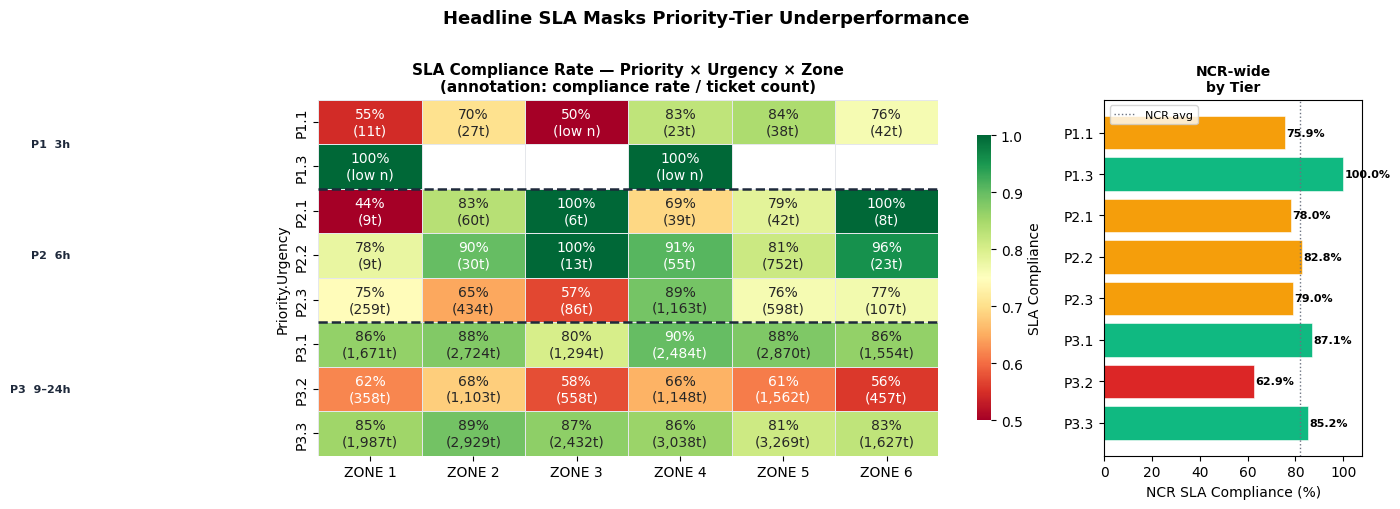

Saved: reports/figures/project1_ncr/pu_zone_sla_heatmap.png


In [6]:
from config import SLA_THRESHOLDS

# Build Priority_Urgency labels and SLA budget per ticket
df['Priority_num'] = pd.to_numeric(df['Priority'], errors='coerce').astype('Int64')
df['Urgency_num']  = pd.to_numeric(df['Urgency'],  errors='coerce').astype('Int64')
df['PU_key']       = df['Priority_num'].astype(str) + '.' + df['Urgency_num'].astype(str)
df['SLA_Budget_h'] = df['PU_key'].map(SLA_THRESHOLDS)
df['PU_Label']     = 'P' + df['Priority_num'].astype(str) + '.' + df['Urgency_num'].astype(str)

if 'SLA_Compliant' not in df.columns:
    df['SLA_Compliant'] = (df['OUTAGEDURATION'] <= df['SLA_Budget_h']).astype(float)

zones_present = sorted(
    df[df['ZONE'].notna() & (df['ZONE'] != 'Unknown')]['ZONE'].unique()
)
tier_order = ['P1.1','P1.2','P1.3','P2.1','P2.2','P2.3','P3.1','P3.2','P3.3']

# Aggregate: SLA% and ticket count per PU_Label × ZONE
pu_zone = (
    df[df['ZONE'].isin(zones_present)]
    .groupby(['PU_Label','ZONE'])
    .agg(
        Tickets      = ('SLA_Compliant','count'),
        SLA_Rate     = ('SLA_Compliant','mean'),
        SLA_Budget_h = ('SLA_Budget_h', 'first'),
    )
    .reset_index()
)

# NCR-wide totals per tier
pu_ncr = (
    df[df['ZONE'].isin(zones_present)]
    .groupby('PU_Label')
    .agg(
        NCR_Tickets  = ('SLA_Compliant','count'),
        NCR_SLA_Rate = ('SLA_Compliant','mean'),
        SLA_Budget_h = ('SLA_Budget_h', 'first'),
    )
)

sla_pivot = pu_zone.pivot(index='PU_Label', columns='ZONE', values='SLA_Rate')
tix_pivot = pu_zone.pivot(index='PU_Label', columns='ZONE', values='Tickets')
tier_order_present = [t for t in tier_order if t in sla_pivot.index]
sla_pivot = sla_pivot.reindex(tier_order_present)
tix_pivot = tix_pivot.reindex(tier_order_present)
pu_ncr    = pu_ncr.reindex(tier_order_present)

sla_pivot['NCR SLA%']    = pu_ncr['NCR_SLA_Rate']
sla_pivot['SLA Budget']  = pu_ncr['SLA_Budget_h'].map('{:.0f}h'.format)
tix_pivot['NCR Total']   = pu_ncr['NCR_Tickets']

display(Markdown('### Table 3 — SLA Compliance Rate by Priority × Urgency × Zone'))
display(Markdown('*Annotation in each cell: SLA rate (ticket count). '
                 'Green = compliant, Red = breach. '
                 'Dashed rows = P1 / P2 / P3 boundaries.*'))

# Build annotated display
import seaborn as sns, matplotlib.pyplot as plt, matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [3, 1]})

# ── Left: full heatmap ───────────────────────────────────────────────────────
ax = axes[0]
heat_data = sla_pivot[zones_present].astype(float)

annot = heat_data.copy().astype(object)
for pu in heat_data.index:
    for zone in zones_present:
        val = heat_data.loc[pu, zone]
        tix = tix_pivot.loc[pu, zone] if pu in tix_pivot.index else 0
        if pd.notna(val) and pd.notna(tix) and tix >= 5:
            annot.loc[pu, zone] = f"{val:.0%}\n({int(tix):,}t)"
        elif pd.notna(val):
            annot.loc[pu, zone] = f"{val:.0%}\n(low n)"
        else:
            annot.loc[pu, zone] = '—'

sns.heatmap(
    heat_data, ax=ax,
    cmap='RdYlGn', vmin=0.5, vmax=1.0,
    annot=annot, fmt='',
    linewidths=0.6, linecolor='#e5e7eb',
    cbar_kws={'label':'SLA Compliance', 'shrink':0.8},
)

# Tier group dividers
p1_rows = sum(1 for t in tier_order_present if t.startswith('P1'))
p2_rows = sum(1 for t in tier_order_present if t.startswith('P2'))
ax.axhline(p1_rows,           color='#1e293b', lw=1.8, ls='--')
ax.axhline(p1_rows + p2_rows, color='#1e293b', lw=1.8, ls='--')

for label, mid in [
    ('P1  3h', p1_rows / 2),
    ('P2  6h', p1_rows + p2_rows / 2),
    ('P3  9–24h', p1_rows + p2_rows + (len(tier_order_present) - p1_rows - p2_rows) / 2),
]:
    ax.text(-0.4, mid, label, va='center', ha='right', fontsize=8,
            fontweight='bold', color='#1e293b',
            transform=ax.get_yaxis_transform())

ax.set_title('SLA Compliance Rate — Priority × Urgency × Zone\n'
             '(annotation: compliance rate / ticket count)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Priority.Urgency')
ax.set_xlabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=0)

# ── Right: NCR-wide bar ────────────────────────────────────────────────────────
ax2 = axes[1]
ncr_sla = sla_pivot['NCR SLA%'].reindex(tier_order_present)
bar_colors = ['#dc2626' if v < 0.75 else '#f59e0b' if v < 0.85 else '#10b981'
              for v in ncr_sla.fillna(0)]
bars = ax2.barh(tier_order_present, ncr_sla * 100,
                color=bar_colors, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, ncr_sla):
    if pd.notna(val):
        ax2.text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=8, fontweight='bold')
ax2.axvline(82, color='#6b7280', ls=':', lw=1, label='NCR avg')
ax2.set_xlim(0, 108)
ax2.set_xlabel('NCR SLA Compliance (%)')
ax2.set_title('NCR-wide\nby Tier', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.invert_yaxis()

plt.suptitle('Headline SLA Masks Priority-Tier Underperformance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

fig_path = 'reports/figures/project1_ncr/pu_zone_sla_heatmap.png'
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [7]:
# ── Key observations ──────────────────────────────────────────────────────────
headline_sla = df[df['ZONE'].isin(zones_present)].groupby('ZONE')['SLA_Compliant'].mean()
p1_tiers = [t for t in tier_order_present if t.startswith('P1')]
p2_tiers = [t for t in tier_order_present if t.startswith('P2')]
p1_by_zone = sla_pivot[zones_present].loc[p1_tiers].mean()
p2_by_zone = sla_pivot[zones_present].loc[p2_tiers].mean()

masked = [
    z for z in zones_present
    if pd.notna(headline_sla.get(z)) and pd.notna(p1_by_zone.get(z))
    and headline_sla[z] >= 0.80 and p1_by_zone[z] < 0.75
]

p32 = pu_zone[pu_zone['PU_Label'] == 'P3.2'].set_index('ZONE').reindex(zones_present)
breach_32 = (1 - p32['SLA_Rate']).fillna(0)

print('Key observations — Priority × Urgency SLA breakdown:')
print()
print(f'  Headline SLA range : {headline_sla.min():.1%} – {headline_sla.max():.1%}')
print(f'  P1 SLA range       : {p1_by_zone.min():.1%} – {p1_by_zone.max():.1%}')
print(f'  P2 SLA range       : {p2_by_zone.min():.1%} – {p2_by_zone.max():.1%}')
print()
if masked:
    print(f'  Aggregate masking (headline ≥80%, P1 <75%): {", ".join(masked)}')
print()
print('  P3.2 (12h SLA) breach rate by zone — highest-volume breach tier:')
for z in zones_present:
    val = breach_32.get(z, 0)
    tix = int(p32.loc[z,'Tickets']) if z in p32.index and pd.notna(p32.loc[z,'Tickets']) else 0
    bar = '█' * int(val * 30)
    print(f'    {z:<8}  {val:.1%}  {bar}  ({tix:,} tickets)')

Key observations — Priority × Urgency SLA breakdown:

  Headline SLA range : 79.6% – 84.5%
  P1 SLA range       : 50.0% – 91.3%
  P2 SLA range       : 65.6% – 90.8%

  Aggregate masking (headline ≥80%, P1 <75%): ZONE 2, ZONE 3

  P3.2 (12h SLA) breach rate by zone — highest-volume breach tier:
    ZONE 1    38.0%  ███████████  (358 tickets)
    ZONE 2    31.6%  █████████  (1,103 tickets)
    ZONE 3    42.5%  ████████████  (558 tickets)
    ZONE 4    34.4%  ██████████  (1,148 tickets)
    ZONE 5    38.9%  ███████████  (1,562 tickets)
    ZONE 6    44.2%  █████████████  (457 tickets)


## 7. Data Caveats

### 7a. Timestamp Integrity

193 tickets (0.5% of NCR) had `DISPATCHDATE` recorded after `RESOLVEDDATE`, producing
negative field time values. These are source system data entry errors — field engineers
logging dispatch actions after ticket closure. They are flagged as
`Timestamp_Integrity = False` and excluded from NOC/ROC and Field time aggregations only.
Volume and SLA metrics are unaffected. See Notebook 02 Section 7 for zone-level breakdown.

The most affected zone was Zone 1, where corrupt timestamps had previously inflated
average NOC time from **15.8h to 83.7h** — a 5× distortion driven by 193 tickets
with an average corrupt dispatch delay of 1,529h.

### 7b. Temporal & Scheduling Context

SLA compliance and MTTR aggregates in this notebook reflect the full Jan 2022–May 2023
period without temporal decomposition. Preliminary analysis indicates that day-of-week
SLA patterns, evening breach concentration, and seasonal volume spikes (Holy Week,
typhoon season) are present in the data and are structurally linked to the Sun–Thu /
Tue–Sat team schedule and the operations team strategy. These patterns
do not affect relative zone rankings but do suppress absolute SLA and MTTR values in
ways that are partially addressable at the management level. Full temporal decomposition
is scoped for **next projects**.

### 7c. Access Constraints Affecting Field Time

Two distinct constraints affect field resolution time and are not interchangeable:

**Lessor Disputes** (`ADMIN-Lessor Related Cause` in RFO data)
Landlord withholding access due to contract, legal, or rental issues. A commercial
relationship problem — not an operational one.

**Building Work Permit Delays** (no RFO tag — absorbed silently into field time)
Sites inside commercial buildings in CBDs require work permits before engineers can
enter. Leaves no trace in current data and inflates `Avg_Field_Time` in high-CBD zones.

| Zone | Cities | CBD Exposure |
|------|--------|-------------|
| ZONE 5 | Makati, Pasay, Taguig, Pateros | 🔴 High — Ayala CBD, BGC |
| ZONE 4 | Manila, Pasig, San Juan, Mandaluyong | 🔴 High — Ortigas, Binondo |
| ZONE 6 | Paranaque, Las Pinas, Muntinlupa, Bacoor | 🟡 Moderate — Aseana, Filinvest |
| ZONE 2 | Quezon City | 🟡 Moderate — Eastwood, Vertis North |
| ZONE 1 | Caloocan, Navotas, Valenzuela | 🟢 Low |
| ZONE 3 | Rizal, Marikina, Malabon | 🟢 Low |

> Field time in high-CBD zones should be treated as an **upper bound** on true
> engineering resolution time until permit request/approval timestamps are
> added to work order records.

## 8. Next Steps

| Finding | Action | Notebook |
|---------|--------|----------|
| Zone 5 field bottleneck | Audit indoor-commercial vs. outdoor site field time split | Project 2 |
| Zone 6 structural gap | RFO distribution analysis by fault category | Project 2 |
| Zone 1 fault density | Preventive maintenance — top 20 recurring-fault sites | Project 2 |
| Zone 4 SLA benchmark | Document permit pre-coordination workflow | Project 2 |
| Timestamp corruption | Log findings in data quality docs; flag in source system | Project 2 |

→ **Proceed to Notebook 04** to generate the visual dashboard.